In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

# Load the resampled training data and the original test data
# These were saved in the 'data/processed/' folder during Task 1
X_train = pd.read_csv('../data/processed/X_train_resampled.csv')
y_train = pd.read_csv('../data/processed/y_train_resampled.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

In [2]:
# Initialize and train the baseline model 
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:, 1]

# Evaluation metrics [cite: 155]
precision, recall, _ = precision_recall_curve(y_test, y_prob_lr)
auc_pr_lr = auc(recall, precision)

print("--- Logistic Regression (Baseline) ---")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-PR: {auc_pr_lr:.4f}")

--- Logistic Regression (Baseline) ---
F1-Score: 0.2780
AUC-PR: 0.3378


In [3]:
# Initialize and train Random Forest [cite: 157]
# Basic tuning: n_estimators and max_depth [cite: 158]
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation [cite: 159]
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
auc_pr_rf = auc(recall_rf, precision_rf)

print("\n--- Random Forest (Ensemble) ---")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-PR: {auc_pr_rf:.4f}")


--- Random Forest (Ensemble) ---
F1-Score: 0.6349
AUC-PR: 0.6173


In [4]:
# Stratified K-Fold Cross-Validation [cite: 161]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='f1')

# Report mean and standard deviation [cite: 162]
print(f"\nRF Cross-Validation F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# Save the best model to the 'models/' folder [cite: 108, 109]
joblib.dump(rf_model, '../models/best_fraud_model.pkl')


RF Cross-Validation F1-Score: 0.8316 (+/- 0.0025)


['../models/best_fraud_model.pkl']

Mean Cross-Validation F1-Score: 0.8525

--- Model Evaluation Results ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     27393
           1       0.54      0.54      0.54      2830

    accuracy                           0.91     30223
   macro avg       0.75      0.75      0.75     30223
weighted avg       0.91      0.91      0.91     30223

AUC-PR Score: 0.6174


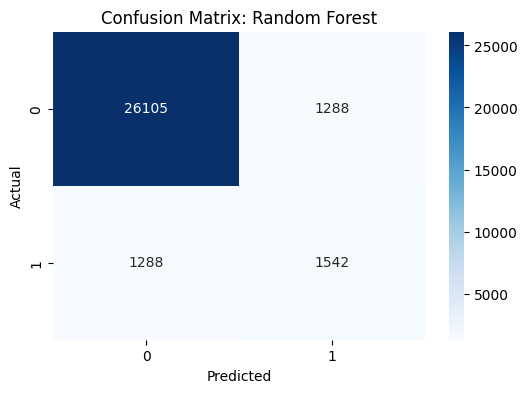

Model saved to models/random_forest_fraud_model.pkl


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    precision_recall_curve, 
    auc, 
    f1_score, 
    recall_score, 
    precision_score
)
from sklearn.model_selection import StratifiedKFold, cross_val_score
import joblib

# --- STEP 1: LOAD THE PROCESSED DATA ---
# Loading the files we saved at the end of Task 1
X_train = pd.read_csv('../data/processed/X_train_resampled.csv')
y_train = pd.read_csv('../data/processed/y_train_resampled.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# --- STEP 2: INITIALIZE THE MODEL ---
# Using Random Forest as our primary Ensemble Model
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=15, 
    random_state=42, 
    n_jobs=-1
)

# --- STEP 3: STRATIFIED K-FOLD CROSS-VALIDATION ---
# This ensures our model is stable across different "folds" of the data
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=skf, scoring='f1')

print(f"Mean Cross-Validation F1-Score: {cv_scores.mean():.4f}")

# --- STEP 4: TRAIN THE FINAL MODEL ---
rf_model.fit(X_train, y_train)

# --- STEP 5: EVALUATION ON TEST SET ---
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate AUC-PR (Area Under Precision-Recall Curve)
# This is much more informative than Accuracy for fraud!
precision, recall, _ = precision_recall_curve(y_test, y_prob)
auc_pr = auc(recall, precision)

print("\n--- Model Evaluation Results ---")
print(classification_report(y_test, y_pred))
print(f"AUC-PR Score: {auc_pr:.4f}")

# --- STEP 6: VISUALIZE CONFUSION MATRIX ---
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# --- STEP 7: SAVE THE MODEL ---
# Save the model to the 'models/' folder for Task 3 (Explainability)
joblib.dump(rf_model, '../models/random_forest_fraud_model.pkl')
print("Model saved to models/random_forest_fraud_model.pkl")

Running Cross-Validation for Logistic Regression (Baseline)...
Running Cross-Validation for Decision Tree...
Running Cross-Validation for Random Forest...
Running Cross-Validation for Gradient Boosting...

--- Model Performance Comparison ---
                            Model  CV Mean F1-Score  Test AUC-PR
0  Logistic Regression (Baseline)          0.704020     0.337829
1                   Decision Tree          0.827883     0.617654
2                   Random Forest          0.831560     0.617251
3               Gradient Boosting          0.836740     0.618315


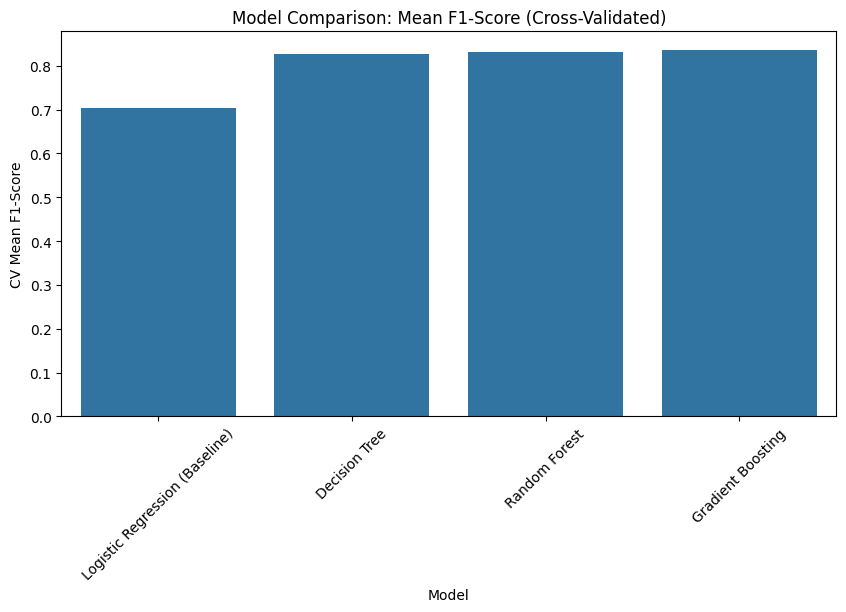

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc, make_scorer, f1_score

# --- STEP 1: LOAD DATA ---
X_train = pd.read_csv('../data/processed/X_train_resampled.csv')
y_train = pd.read_csv('../data/processed/y_train_resampled.csv').values.ravel()
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').values.ravel()

# --- STEP 2: DEFINE MODELS ---
models = {
    "Logistic Regression (Baseline)": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
}

# --- STEP 3: EXECUTABLE COMPARISON (Task 2b) ---
# We use Stratified 5-Fold Cross-Validation as requested in feedback
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1': 'f1', 'auc_pr': make_scorer(f1_score)} # Simplified for the loop

results = []

for name, model in models.items():
    print(f"Running Cross-Validation for {name}...")
    cv_results = cross_validate(model, X_train, y_train, cv=skf, scoring='f1', return_train_score=False)
    
    # Fit on full training data to evaluate on Test Set
    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    auc_pr = auc(recall, precision)
    
    results.append({
        "Model": name,
        "CV Mean F1-Score": cv_results['test_score'].mean(),
        "Test AUC-PR": auc_pr
    })

# --- STEP 4: MODEL COMPARISON TABLE ---
comparison_df = pd.DataFrame(results)
print("\n--- Model Performance Comparison ---")
print(comparison_df)

# Visualization for GitHub
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x="Model", y="CV Mean F1-Score")
plt.title("Model Comparison: Mean F1-Score (Cross-Validated)")
plt.xticks(rotation=45)
plt.show()